# Decision Tree Machine Learning for Credit Risk Analysis

This notebook follows the same overall process as your KNIME workflow:

- Load the corporate rating dataset.
- Handle missing values and numeric outliers.
- Assign grouped class labels.
- Select modeling features.
- Split the data.
- Balance the training set with SMOTE.
- Train a Decision Tree.
- Apply the model.
- Evaluate the results.

The class target is `RatingGroup`, not the raw `Rating`.

Why:
- Raw ratings such as `AAA`, `AA`, `A`, `BBB`, `BB`, `B`, `CCC`, `CC`, `C`, `D` are heavily imbalanced.
- Grouping makes the model easier to explain and closer to a credit risk use case.
- This notebook mirrors the KNIME node order more closely than the previous generic sklearn flow.


## 1. Install and import libraries

What this part does:

- Imports the tools needed for the model.
- pandas handles the dataset.
- numpy supports numerical work.
- matplotlib and seaborn create charts.
- scikit-learn builds the Decision Tree.
- joblib saves the trained model.


In [10]:
# Run this only if the imports below fail.
# In VS Code terminal, you may also run:
# pip install pandas scikit-learn imbalanced-learn matplotlib seaborn joblib shap

# !pip install pandas scikit-learn imbalanced-learn matplotlib seaborn joblib shap


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 143


## 2. Load the dataset

What this part does:

- Loads the corporate rating CSV file.
- The dataset has 2,029 rows and 31 columns.
- Each row represents a company credit rating record.


In [ ]:
from pathlib import Path

# "data/set A corporate_rating.csv" only resolves if Jupyter's cwd is the
# repo root; if it's launched from docs/ instead (common in VS Code), this
# fails, and the previous fallback pointed at one specific person's Downloads
# folder. Check both plausible cwd locations instead.
def _find_repo_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "data" / "set A corporate_rating.csv").exists():
            return candidate
    return Path.cwd()

DATA_PATH = _find_repo_root() / "data" / "set A corporate_rating.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Make sure 'data/set A corporate_rating.csv' "
        "exists in the repo root."
    )

df = pd.read_csv(DATA_PATH)

print("Resolved DATA_PATH:", DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


## 3. Understand the data, handle missing values, and treat numeric outliers

This step matches the early KNIME cleanup nodes.

Check:
- Number of rows and columns.
- Column names.
- Data types.
- Missing values.
- Numeric outliers.
- Rating distribution.

This gives you the same kind of data audit you would do before the Rule Engine and SMOTE steps in KNIME.


In [13]:
def cap_numeric_outliers(frame, numeric_columns, factor=1.5):
    cleaned = frame.copy()
    summary = []
    for column in numeric_columns:
        q1 = cleaned[column].quantile(0.25)
        q3 = cleaned[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        before = cleaned[column].copy()
        cleaned[column] = cleaned[column].clip(lower=lower_bound, upper=upper_bound)
        capped_count = int((before != cleaned[column]).sum())
        summary.append({
            "Column": column,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Values Capped": capped_count
        })
    return cleaned, pd.DataFrame(summary)

print("Rows and columns:", df.shape)
print()
print("Column names:")
print(df.columns.tolist())
print()
print("Data types before cleanup:")
display(df.dtypes)
print()
print("Missing values before cleanup:")
display(df.isnull().sum().sort_values(ascending=False))
print()
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df, outlier_summary = cap_numeric_outliers(df, numeric_columns)
print()
print("Numeric outlier treatment summary:")
display(outlier_summary)
print()
print("Data types after cleanup:")
display(df.dtypes)
print()
print("Original rating distribution:")
display(df["Rating"].value_counts())


Rows and columns: (2029, 31)

Column names:
['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

Data types before cleanup:


Rating                                 object
Name                                   object
Symbol                                 object
Rating Agency Name                     object
Date                                   object
Sector                                 object
currentRatio                          float64
quickRatio                            float64
cashRatio                             float64
daysOfSalesOutstanding                float64
netProfitMargin                       float64
pretaxProfitMargin                    float64
grossProfitMargin                     float64
operatingProfitMargin                 float64
returnOnAssets                        float64
returnOnCapitalEmployed               float64
returnOnEquity                        float64
assetTurnover                         float64
fixedAssetTurnover                    float64
debtEquityRatio                       float64
debtRatio                             float64
effectiveTaxRate                  


Missing values before cleanup:


Rating                                0
Name                                  0
Symbol                                0
Rating Agency Name                    0
Date                                  0
Sector                                0
currentRatio                          0
quickRatio                            0
cashRatio                             0
daysOfSalesOutstanding                0
netProfitMargin                       0
pretaxProfitMargin                    0
grossProfitMargin                     0
operatingProfitMargin                 0
returnOnAssets                        0
returnOnCapitalEmployed               0
returnOnEquity                        0
assetTurnover                         0
fixedAssetTurnover                    0
debtEquityRatio                       0
debtRatio                             0
effectiveTaxRate                      0
freeCashFlowOperatingCashFlowRatio    0
freeCashFlowPerShare                  0
cashPerShare                          0




Numeric outlier treatment summary:


,Column,Lower Bound,Upper Bound,Values Capped
0,currentRatio,-0.570512,3.809332,132
1,quickRatio,-0.673667,2.730312,168
2,cashRatio,-0.610784,1.366320,141
3,daysOfSalesOutstanding,-31.722612,113.951268,87
4,netProfitMargin,-0.119695,0.255508,232
5,pretaxProfitMargin,-0.153023,0.323434,236
6,grossProfitMargin,-0.691722,1.774542,8
7,operatingProfitMargin,-0.152745,0.373536,188
8,returnOnAssets,-0.068263,0.164906,167
9,returnOnCapitalEmployed,-0.132275,0.295423,153



Data types after cleanup:


Rating                                 object
Name                                   object
Symbol                                 object
Rating Agency Name                     object
Date                                   object
Sector                                 object
currentRatio                          float64
quickRatio                            float64
cashRatio                             float64
daysOfSalesOutstanding                float64
netProfitMargin                       float64
pretaxProfitMargin                    float64
grossProfitMargin                     float64
operatingProfitMargin                 float64
returnOnAssets                        float64
returnOnCapitalEmployed               float64
returnOnEquity                        float64
assetTurnover                         float64
fixedAssetTurnover                    float64
debtEquityRatio                       float64
debtRatio                             float64
effectiveTaxRate                  


Original rating distribution:


Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64

## 4. Assign class labels

The KNIME workflow uses a Rule Engine to create the grouped class column.

I did the same thing here by converting the raw `Rating` into `RatingGroup`.

What this part does:

The original Rating column has too many classes.

Some classes have too few records.

Example: D has only 1 record.

So the ratings were grouped into 4 categories:
- Investment-High
- Investment-Low
- Speculative
- Distressed


Grouped rating distribution:


RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64

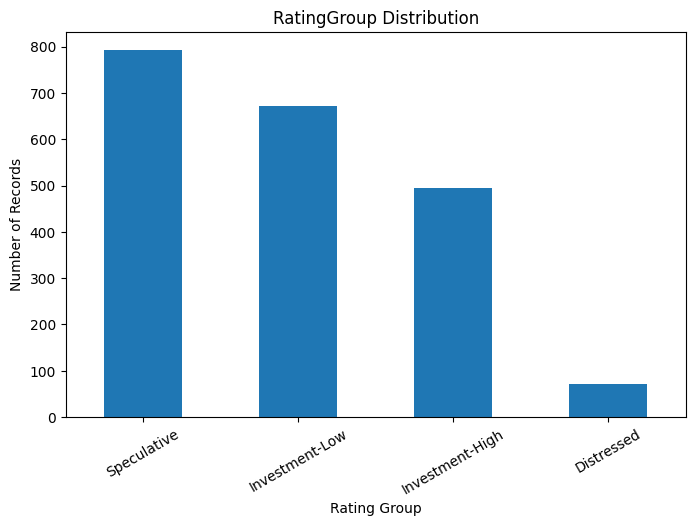

In [14]:
def group_rating(rating):
    if rating in ["AAA", "AA", "A"]:
        return "Investment-High"
    elif rating == "BBB":
        return "Investment-Low"
    elif rating in ["BB", "B"]:
        return "Speculative"
    elif rating in ["CCC", "CC", "C", "D"]:
        return "Distressed"
    else:
        return "Unknown"

df["RatingGroup"] = df["Rating"].apply(group_rating)
df = df[df["RatingGroup"] != "Unknown"].copy()

print("Grouped rating distribution:")
display(df["RatingGroup"].value_counts())

plt.figure(figsize=(8, 5))
df["RatingGroup"].value_counts().plot(kind="bar")
plt.title("RatingGroup Distribution")
plt.xlabel("Rating Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.show()


## 5. Select features for modeling

The target variable is RatingGroup. 
For the input features, I used the financial ratios and Sector. 
I removed company identifiers and metadata because they do not directly represent financial risk. 
I also removed the original Rating column to avoid data leakage.


In [15]:
target_col = "RatingGroup"

drop_cols = [
    "Rating",
    "RatingGroup",
    "Name",
    "Symbol",
    "Rating Agency Name",
    "Date"
]

X = df.drop(columns=drop_cols)
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", target_col)
print()
print("Numeric features:", numeric_features)
print()
print("Categorical features:", categorical_features)

display(X.head())
display(y.head())


Target column: RatingGroup

Numeric features: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

Categorical features: ['Sector']


,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,Consumer Durables,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,14.764294,0.058638,3.906655
1,Consumer Durables,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,14.764294,0.067239,4.002846
2,Consumer Durables,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,14.764294,0.074426,3.483510
3,Consumer Durables,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,...,0.706351,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,Consumer Durables,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,14.764294,0.058065,3.857790


0    Investment-High
1     Investment-Low
2     Investment-Low
3     Investment-Low
4     Investment-Low
Name: RatingGroup, dtype: object

## 6. Split into training and testing data

I split the data into 70 percent training and 30 percent testing. The training set is used to train the model, while the testing set is kept unseen for evaluation. I used stratify so that each credit risk group has a similar proportion in both sets.

We use `stratify=y` so each rating group keeps a similar percentage in both training and testing data.

stratify=y means:

Split the data while keeping the same class balance as y. (y = RatingGroup)

I used stratify=y because my target variable, RatingGroup, is imbalanced. Some classes, such as Speculative and Investment-Low, have many records, while Distressed has much fewer records. Stratified splitting keeps the class proportions similar in both the training and testing sets. This makes the evaluation fairer because the test set represents the original dataset more accurately.


This matches the KNIME Table Partitioner settings:
- Relative split: 70%
- Sampling strategy: Stratified
- Fixed random seed: 143


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print()
print("Training target distribution:")
display(y_train.value_counts())
print()
print("Testing target distribution:")
display(y_test.value_counts())


Training rows: 1420
Testing rows: 609

Training target distribution:


RatingGroup
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50
Name: count, dtype: int64


Testing target distribution:


RatingGroup
Speculative        238
Investment-Low     201
Investment-High    148
Distressed          22
Name: count, dtype: int64

## 7. Balance classes with SMOTE and train the Decision Tree model

What it does:

Creates preprocessing steps.

Numeric columns use median imputation.

Sector uses most frequent imputation and one-hot encoding.

Applies preprocessing to the training and testing data.

Applies SMOTE only to the training data.

Trains the Decision Tree model using the balanced training data.



Why it matters:

Distressed has far fewer training records.

SMOTE creates synthetic examples for smaller classes.

This gives the model more balanced training data.

SMOTE is not applied to test data because the test set should stay real and unseen.


In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("Training target distribution before SMOTE:")
display(y_train.value_counts())
print()
print("Training target distribution after SMOTE:")
display(pd.Series(y_train_balanced).value_counts())

best_model = DecisionTreeClassifier(
    criterion="gini",
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
best_model.fit(X_train_balanced, y_train_balanced)

feature_names = preprocessor.get_feature_names_out()
labels = best_model.classes_

best_model


Training target distribution before SMOTE:


RatingGroup
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50
Name: count, dtype: int64


Training target distribution after SMOTE:


RatingGroup
Investment-High    554
Speculative        554
Investment-Low     554
Distressed         554
Name: count, dtype: int64

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",143
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

## 8. Apply Decision Tree Model

Uses the trained model to predict the test data.

Produces predicted RatingGroup values.

Produces class probabilities.

Also tests one sample company.


In [18]:
test_pred = best_model.predict(X_test_processed)
test_proba = best_model.predict_proba(X_test_processed)

sample_company = X_test.iloc[[0]].copy()
sample_company_processed = preprocessor.transform(sample_company)
sample_prediction = best_model.predict(sample_company_processed)[0]
sample_prediction_proba = best_model.predict_proba(sample_company_processed)[0]

print("Sample company input:")
display(sample_company)

print("Predicted RatingGroup:", sample_prediction)

proba_df = pd.DataFrame({
    "RatingGroup": best_model.classes_,
    "Normalized Class Distribution": sample_prediction_proba
}).sort_values(by="Normalized Class Distribution", ascending=False)

display(proba_df)


Sample company input:


,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
568,Consumer Durables,0.854623,0.495669,0.097496,44.783228,0.054489,0.071809,0.356301,0.086762,0.068252,...,0.313109,0.542064,3.435954,2.380429,-0.370441,0.071809,22.83815,6.338648,0.124039,4.581547


Predicted RatingGroup: Investment-High


,RatingGroup,Normalized Class Distribution
1,Investment-High,0.500
2,Investment-Low,0.375
3,Speculative,0.125
0,Distressed,0.000


## 9. Evaluate Model Performance

This is the KNIME Scorer step.

Use both accuracy and weighted F1-score because the classes are still not perfectly balanced after cleanup.

Why weighted F1-score matters:

- The dataset is imbalanced.
- Accuracy alone does not show performance across all classes.
- Weighted F1-score considers precision, recall, and class size.


Accuracy: 0.5205
Weighted F1-score: 0.5252

Classification Report:
                 precision    recall  f1-score   support

     Distressed       0.18      0.32      0.23        22
Investment-High       0.58      0.53      0.55       148
 Investment-Low       0.50      0.51      0.51       201
    Speculative       0.56      0.54      0.55       238

       accuracy                           0.52       609
      macro avg       0.46      0.48      0.46       609
   weighted avg       0.53      0.52      0.53       609



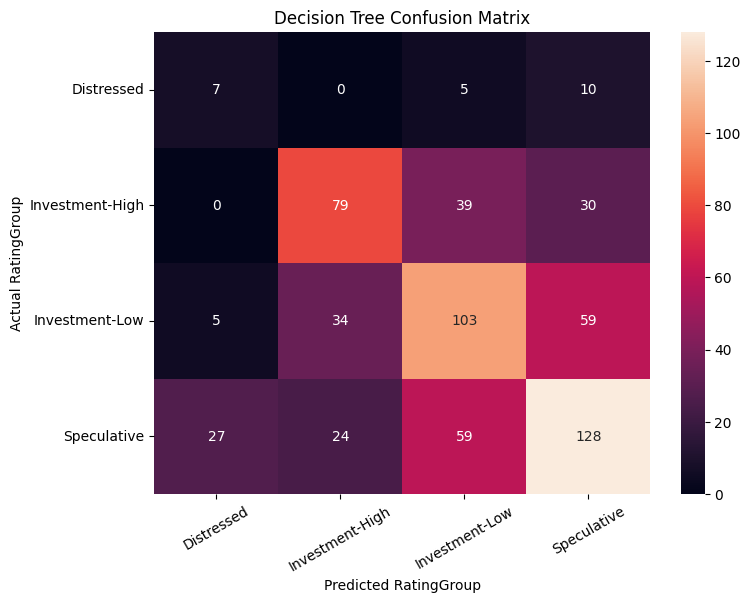

In [19]:
accuracy = accuracy_score(y_test, test_pred)
weighted_f1 = f1_score(y_test, test_pred, average="weighted")

print("Accuracy:", round(accuracy, 4))
print("Weighted F1-score:", round(weighted_f1, 4))
print()
print("Classification Report:")
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted RatingGroup")
plt.ylabel("Actual RatingGroup")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()


## 10. Show the Decision Tree

This is useful for presentation because Decision Trees are easier to explain than many other models.

Limit the plot depth so it stays readable.


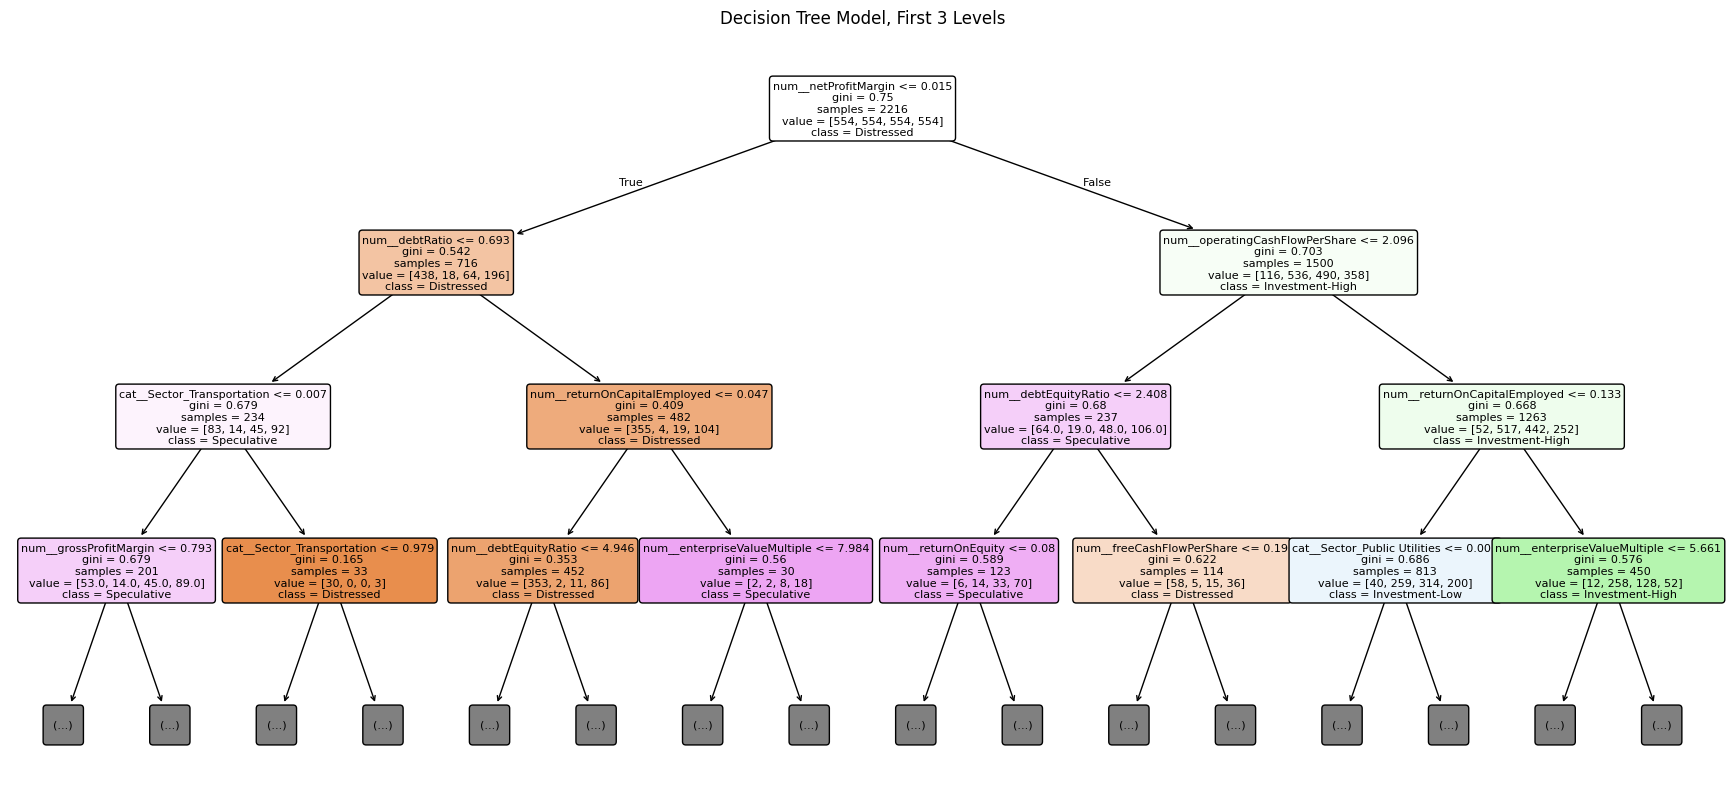

In [20]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_model,
    feature_names=feature_names,
    class_names=best_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Model, First 3 Levels")
plt.show()


## 11. Export tree rules as text

Use this when you need to explain model logic in words.

Example explanation:
- The tree checks a financial ratio.
- It compares the ratio against a threshold.
- It moves left or right based on the result.
- The final leaf gives the predicted rating group.


In [21]:
trained_tree = best_model

tree_rules = export_text(
    trained_tree,
    feature_names=list(feature_names),
    max_depth=4
)

print(tree_rules[:5000])


|--- num__netProfitMargin <= 0.01
|   |--- num__debtRatio <= 0.69
|   |   |--- cat__Sector_Transportation <= 0.01
|   |   |   |--- num__grossProfitMargin <= 0.79
|   |   |   |   |--- num__operatingCashFlowPerShare <= 2.74
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- num__operatingCashFlowPerShare >  2.74
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- num__grossProfitMargin >  0.79
|   |   |   |   |--- num__effectiveTaxRate <= 0.31
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- num__effectiveTaxRate >  0.31
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- cat__Sector_Transportation >  0.01
|   |   |   |--- cat__Sector_Transportation <= 0.98
|   |   |   |   |--- class: Distressed
|   |   |   |--- cat__Sector_Transportation >  0.98
|   |   |   |   |--- class: Speculative
|   |--- num__debtRatio >  0.69
|   |   |--- num__returnOnCapitalEmployed <= 0.05
|   |   |   |--- num__debtEquityRatio <= 4.

In [22]:
trained_tree = best_model


## 12. Feature importance

What it does:

- Shows which features influenced the Decision Tree most.
- Higher importance means the model used that feature more for splitting.

Why it matters:

- These features match credit risk logic.
- Profitability, cash flow, and debt level affect company risk.


,Feature,Importance
4,num__netProfitMargin,0.189416
22,num__operatingCashFlowPerShare,0.076400
14,num__debtRatio,0.053728
9,num__returnOnCapitalEmployed,0.049076
18,num__cashPerShare,0.048389
21,num__enterpriseValueMultiple,0.042847
6,num__grossProfitMargin,0.041518
8,num__returnOnAssets,0.037120
2,num__cashRatio,0.034907
17,num__freeCashFlowPerShare,0.033485


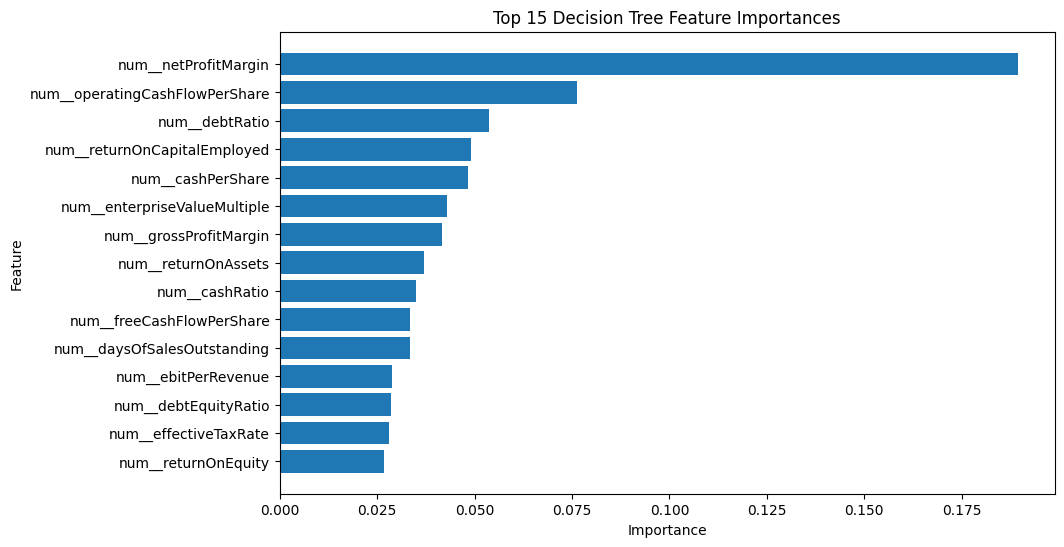

In [23]:
importances = trained_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Top 15 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 13. Predict credit risk for one company record

This section simulates how the model would work in a web application.

A company submits financial ratios.

The model predicts a credit risk group and returns the normalized class distribution, similar to the KNIME predictor option that appends class probabilities.


In [24]:
sample_company = X_test.iloc[[0]].copy()
sample_company_processed = preprocessor.transform(sample_company)
prediction = best_model.predict(sample_company_processed)[0]
prediction_proba = best_model.predict_proba(sample_company_processed)[0]

print("Sample company input:")
display(sample_company)

print("Predicted RatingGroup:", prediction)

proba_df = pd.DataFrame({
    "RatingGroup": best_model.classes_,
    "Normalized Class Distribution": prediction_proba
}).sort_values(by="Normalized Class Distribution", ascending=False)

display(proba_df)


Sample company input:


,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
568,Consumer Durables,0.854623,0.495669,0.097496,44.783228,0.054489,0.071809,0.356301,0.086762,0.068252,...,0.313109,0.542064,3.435954,2.380429,-0.370441,0.071809,22.83815,6.338648,0.124039,4.581547


Predicted RatingGroup: Investment-High


,RatingGroup,Normalized Class Distribution
1,Investment-High,0.500
2,Investment-Low,0.375
3,Speculative,0.125
0,Distressed,0.000


## 14. Save the trained model

This creates a `.joblib` file.

The saved bundle includes the fitted preprocessor and the trained tree so inference can match the training flow.


In [25]:
deployment_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

MODEL_PATH = "decision_tree_credit_risk_model.joblib"
joblib.dump(deployment_model, MODEL_PATH)

print("Model saved as:", MODEL_PATH)


Model saved as: decision_tree_credit_risk_model.joblib


## 15. Optional deployment note

If you use the saved bundle in a web app, pass the raw company row into the bundle and call `.predict()` on the saved pipeline.


In [26]:
print("The saved bundle includes preprocessing, the trained tree, and probability output.")


The saved bundle includes preprocessing, the trained tree, and probability output.
